In [1]:
import pandas as pd
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt

In [3]:
county_boundary = gpd.read_file("../data/processed/county_boundary.shp")

In [4]:
# osmnx needs crs 4326 (WGS84)
county_boundary4326 = county_boundary.to_crs(4326)

In [5]:
G = ox.graph_from_polygon(
    county_boundary4326.geometry.iloc[0],
    network_type="drive"
)

In [6]:
len(G.nodes)

10271

In [7]:
len(G.edges)

25979

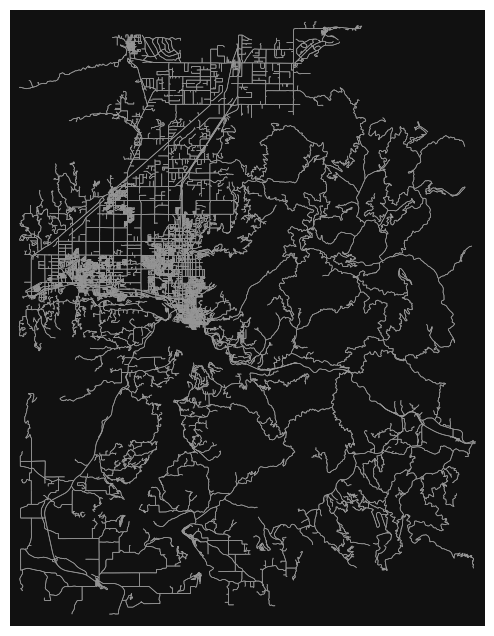

In [8]:
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_linewidth=0.5,
    show=False,
    close=False
)

In [9]:
ox.save_graphml(G, "../data/processed/kootenai_drive.graphml")

In [ ]:
G = ox.load_graphml("../data/processed/kootenai_drive.graphml")

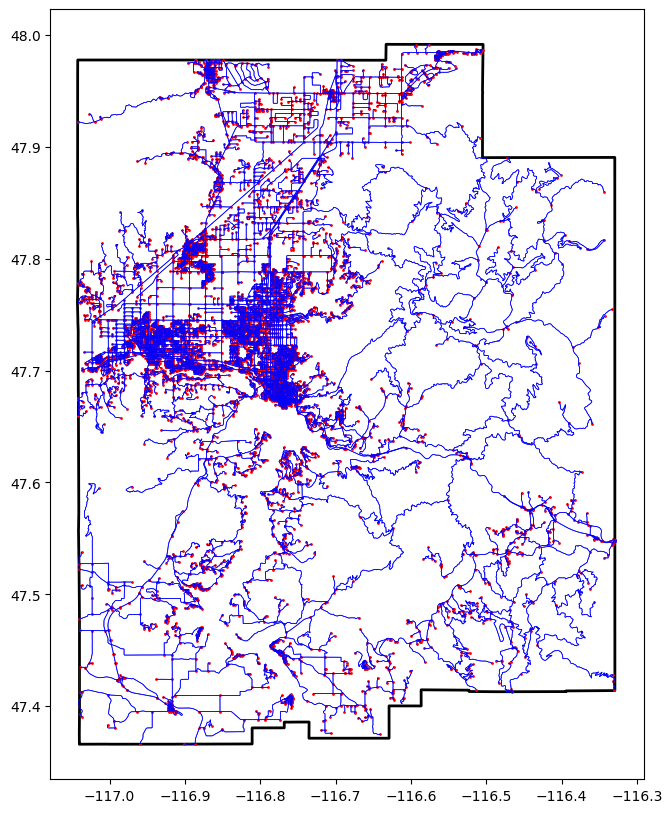

In [ ]:
nodes, edges = ox.graph_to_gdfs(G)

fig, ax = plt.subplots(figsize=(10, 10))

county_boundary4326.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=2
)

nodes.plot(
    ax=ax,
    markersize=1,
    color="red"
)

edges.plot(
    ax=ax,
    linewidth=0.5,
    edgecolor="blue"
)

plt.show()